# SEIRS-SEI Malaria Model — Weighted Force of Infection Calibration

Calibrating **b1** and **b2** (transmission probabilities) with **time-weighted optimization**.

## Problem Statement

The force of infection parameters control the transmission efficiency between humans and mosquitoes. This calibration uses previously fitted humidity parameters (H0, k, phi) and human transmission parameters (tau_H, gamma, omega).

**Parameters being calibrated:**
- **b1**: mosquito-to-human transmission probability
- **b2**: human-to-mosquito transmission probability

**FoI equations:**
- `foi_h = a(T) * b2 * (I_M / N)` — force of infection on humans
- `foi_m = a(T) * b1 * (I_H / N)` — force of infection on mosquitoes

**Weight Decay Methods:**
- **Exponential**: `weight = W0 * exp(-rate * days)` - Smooth, continuous decay
- **Step**: Higher weight for first year, then lower weight
- **Inverse**: `weight = W0 * (1 / (1 + days/365))` - Year-based decay

**Default values**: b1=0.04, b2=0.09

---
**Resumable execution**: Results are saved to `calibration_results_foi.json` after each section.
If the notebook is interrupted, re-run from the top — completed sections will be loaded from file and skipped.

In [2]:
from weighted_optimization_shared import *
%matplotlib inline
import warnings, json, os
warnings.filterwarnings("ignore")
from scipy.optimize import minimize
import itertools

Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
Loaded fitted humidity params from exponential: H0=44.9999, k=0.600000, phi=0.100001
Loaded fitted human params from exponential: tau_H=21.0000, gamma=0.008333, omega=0.005556

Initial human compartments in 2012: N=8914, S_H=5365, E_H=446, I_H=1766, R_H=1337
Initial mosquito compartments in 2012: M=89140, S_M=85576, E_M=2673, I_M=891


In [3]:
RESULTS_FILE = os.path.join(os.getcwd(), 'calibration_results_foi.json')

b1_candidates = [0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]
b2_candidates = [0.005, 0.01, 0.02, 0.04, 0.06, 0.09, 0.12, 0.15, 0.20]
bounds = [(0.001, 1.0), (0.001, 1.0)]
decay_rate = 0.005
initial_weight = 5.0
step_initial_weight = 5.0
step_later_weight = 1.0
inverse_scale = 365

saved = {}
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, 'r') as f:
        saved = json.load(f)
    print(f"Loaded saved results from {RESULTS_FILE}")
    for method, params in saved.items():
        print(f"  {method}: b1={params['b1']:.6f}, b2={params['b2']:.6f}")
else:
    print("No saved results found — will run all grid searches.")

if 'exponential' in saved:
    b1_optimal_exp = saved['exponential']['b1']
    b2_optimal_exp = saved['exponential']['b2']
if 'step' in saved:
    b1_optimal_step = saved['step']['b1']
    b2_optimal_step = saved['step']['b2']
if 'inverse' in saved:
    b1_optimal_inv = saved['inverse']['b1']
    b2_optimal_inv = saved['inverse']['b2']

Loaded saved results from C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_foi.json
  exponential: b1=0.040000, b2=0.090000
  step: b1=0.150003, b2=0.019998
  inverse: b1=0.150008, b2=0.020000


In [4]:
def save_result(method_name, b1, b2):
    data = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}
    data[method_name] = {'b1': float(b1), 'b2': float(b2)}
    with open(RESULTS_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"  Saved {method_name} results to {RESULTS_FILE}")

---
## Section 1: Understanding the Weighting Approach

Before calibrating, let's understand how different weight functions affect the optimization.

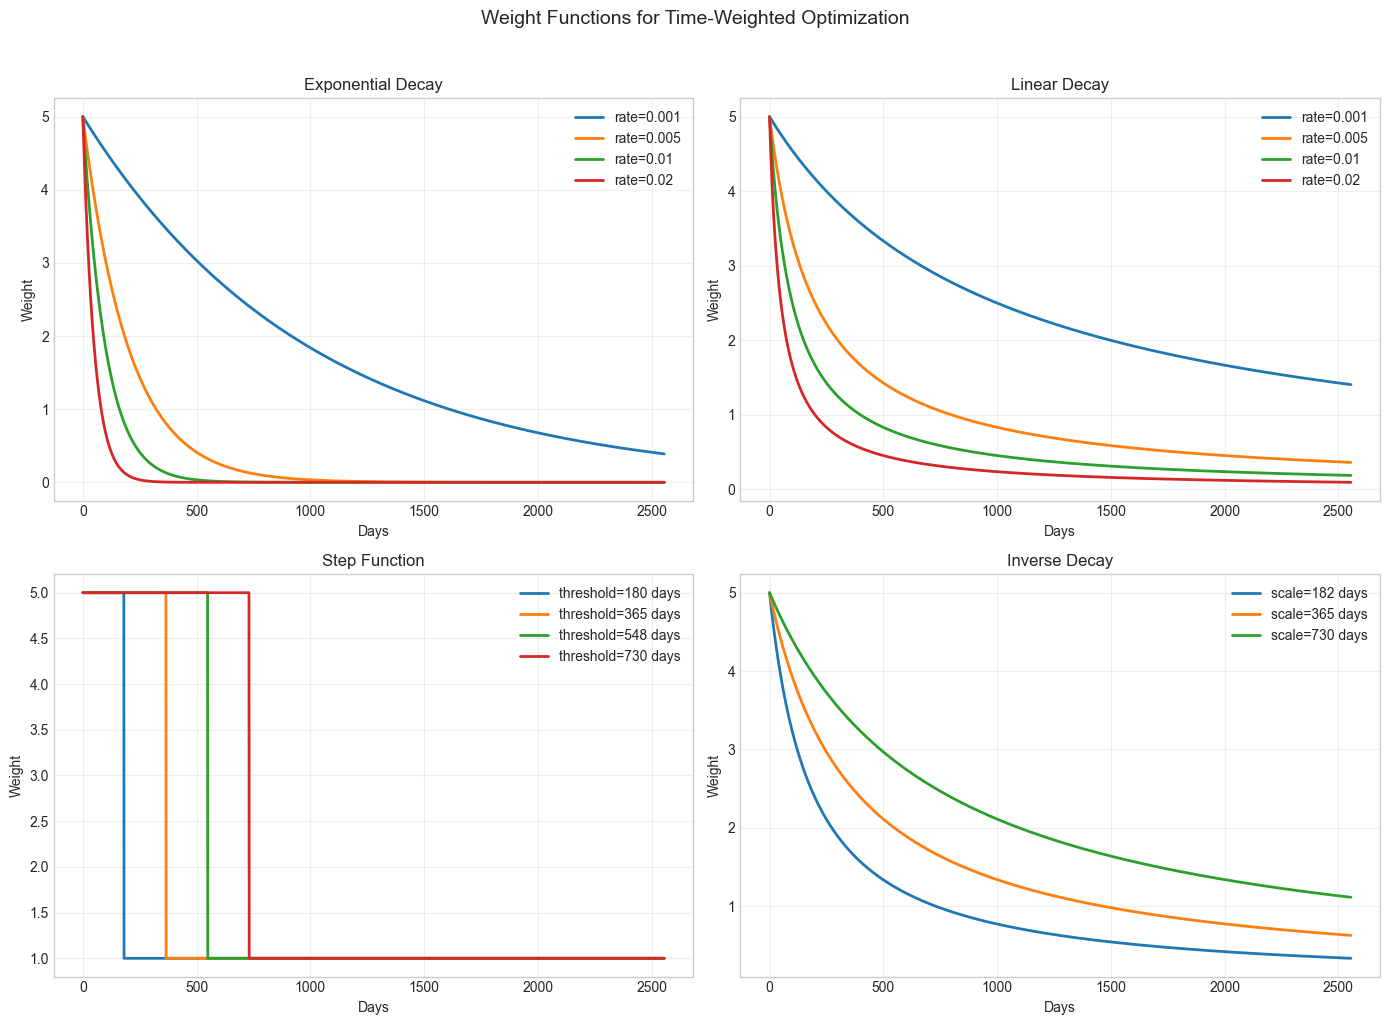

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
days = np.arange(0, 2556, 1)

ax1 = axes[0, 0]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax1.plot(days, 5.0 * np.exp(-rate * days), linewidth=2, label=f'rate={rate}')
ax1.set_title('Exponential Decay'); ax1.set_xlabel('Days'); ax1.set_ylabel('Weight'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax2.plot(days, 5.0 / (1 + rate * days), linewidth=2, label=f'rate={rate}')
ax2.set_title('Linear Decay'); ax2.set_xlabel('Days'); ax2.set_ylabel('Weight'); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
for thresh in [180, 365, 548, 730]:
    w = np.where(days <= thresh, 5.0, 1.0)
    ax3.plot(days, w, linewidth=2, label=f'threshold={thresh} days')
ax3.set_title('Step Function'); ax3.set_xlabel('Days'); ax3.set_ylabel('Weight'); ax3.legend(); ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for scale in [182, 365, 730]:
    ax4.plot(days, 5.0 * (1.0 / (1.0 + days / scale)), linewidth=2, label=f'scale={scale} days')
ax4.set_title('Inverse Decay'); ax4.set_xlabel('Days'); ax4.set_ylabel('Weight'); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle('Weight Functions for Time-Weighted Optimization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2: Grid Search with Exponential Weighting

In [8]:
if 'exponential' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Exponential Weighting")
    print("=" * 70)
    grid_size = len(b1_candidates) * len(b2_candidates)
    print(f"Grid size: {len(b1_candidates)} x {len(b2_candidates)} = {grid_size}")
    print(f"Weight: exponential decay, rate={decay_rate}, initial_weight={initial_weight}")
    print()

    best_params_exp = None
    best_mse_exp = 1e15

    for b1v, b2v in itertools.product(b1_candidates, b2_candidates):
        mse = objective_function_weighted_foi([b1v, b2v],
                                         weight_decay='exponential',
                                         decay_rate=decay_rate,
                                         initial_weight=initial_weight)
        if mse < best_mse_exp:
            best_mse_exp = mse
            best_params_exp = (b1v, b2v)
        print(f"  b1={b1v:.4f}, b2={b2v:.4f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Exponential): b1={best_params_exp[0]:.4f}, b2={best_params_exp[1]:.4f}")
    print(f"  Weighted MSE = {best_mse_exp:,.2f}")
else:
    print("Exponential results already loaded — skipping grid search.")
    best_params_exp = (b1_optimal_exp, b2_optimal_exp)

Exponential results already loaded — skipping grid search.


In [9]:
if 'exponential' not in saved:
    print("Fine optimization with L-BFGS-B (Exponential)...")
    result_exp = minimize(
        lambda p: objective_function_weighted_foi(p, weight_decay='exponential',
                                             decay_rate=decay_rate, initial_weight=initial_weight),
        list(best_params_exp), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    b1_optimal_exp, b2_optimal_exp = result_exp.x
    print(f"  b1={b1_optimal_exp:.6f}, b2={b2_optimal_exp:.6f}")
    print(f"  Weighted MSE = {result_exp.fun:,.2f}")
    save_result('exponential', b1_optimal_exp, b2_optimal_exp)
else:
    print(f"Exponential: b1={b1_optimal_exp:.6f}, b2={b2_optimal_exp:.6f}")

Exponential: b1=0.040000, b2=0.090000


---
## Section 3: Grid Search with Step Function Weighting

In [11]:
if 'step' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Step Function Weighting")
    print("=" * 70)
    grid_size = len(b1_candidates) * len(b2_candidates)
    print(f"Grid size: {len(b1_candidates)} x {len(b2_candidates)} = {grid_size}")
    print(f"Weight: step (first year: {step_initial_weight}x, after: {step_later_weight}x)")
    print()

    best_params_step = None
    best_mse_step = 1e15

    for b1v, b2v in itertools.product(b1_candidates, b2_candidates):
        mse = objective_function_weighted_foi([b1v, b2v],
                                         weight_decay='step',
                                         initial_weight=step_initial_weight,
                                         step_later_weight=step_later_weight)
        if mse < best_mse_step:
            best_mse_step = mse
            best_params_step = (b1v, b2v)
        print(f"  b1={b1v:.4f}, b2={b2v:.4f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Step): b1={best_params_step[0]:.4f}, b2={best_params_step[1]:.4f}")
    print(f"  Weighted MSE = {best_mse_step:,.2f}")
else:
    print("Step results already loaded — skipping grid search.")
    best_params_step = (b1_optimal_step, b2_optimal_step)

Step results already loaded — skipping grid search.


In [12]:
if 'step' not in saved:
    print("Fine optimization with L-BFGS-B (Step)...")
    result_step = minimize(
        lambda p: objective_function_weighted_foi(p, weight_decay='step',
                                             initial_weight=step_initial_weight,
                                             step_later_weight=step_later_weight),
        list(best_params_step), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    b1_optimal_step, b2_optimal_step = result_step.x
    print(f"  b1={b1_optimal_step:.6f}, b2={b2_optimal_step:.6f}")
    print(f"  Weighted MSE = {result_step.fun:,.2f}")
    save_result('step', b1_optimal_step, b2_optimal_step)
else:
    print(f"Step: b1={b1_optimal_step:.6f}, b2={b2_optimal_step:.6f}")

Step: b1=0.150003, b2=0.019998


---
## Section 4: Grid Search with Inverse Decay Weighting

In [14]:
if 'inverse' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Inverse Decay Weighting")
    print("=" * 70)
    grid_size = len(b1_candidates) * len(b2_candidates)
    print(f"Grid size: {len(b1_candidates)} x {len(b2_candidates)} = {grid_size}")
    print(f"Weight: inverse decay, scale={inverse_scale} days")
    print()

    best_params_inv = None
    best_mse_inv = 1e15

    for b1v, b2v in itertools.product(b1_candidates, b2_candidates):
        mse = objective_function_weighted_foi([b1v, b2v],
                                         weight_decay='inverse',
                                         initial_weight=initial_weight,
                                         inverse_scale=inverse_scale)
        if mse < best_mse_inv:
            best_mse_inv = mse
            best_params_inv = (b1v, b2v)
        print(f"  b1={b1v:.4f}, b2={b2v:.4f} -> Weighted MSE={mse:>12,.2f}")

    print(f"\nBest from grid (Inverse): b1={best_params_inv[0]:.4f}, b2={best_params_inv[1]:.4f}")
    print(f"  Weighted MSE = {best_mse_inv:,.2f}")
else:
    print("Inverse results already loaded — skipping grid search.")
    best_params_inv = (b1_optimal_inv, b2_optimal_inv)

Inverse results already loaded — skipping grid search.


In [15]:
if 'inverse' not in saved:
    print("Fine optimization with L-BFGS-B (Inverse)...")
    result_inv = minimize(
        lambda p: objective_function_weighted_foi(p, weight_decay='inverse',
                                             initial_weight=initial_weight,
                                             inverse_scale=inverse_scale),
        list(best_params_inv), method='L-BFGS-B', bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-8}
    )
    b1_optimal_inv, b2_optimal_inv = result_inv.x
    print(f"  b1={b1_optimal_inv:.6f}, b2={b2_optimal_inv:.6f}")
    print(f"  Weighted MSE = {result_inv.fun:,.2f}")
    save_result('inverse', b1_optimal_inv, b2_optimal_inv)
else:
    print(f"Inverse: b1={b1_optimal_inv:.6f}, b2={b2_optimal_inv:.6f}")

Inverse: b1=0.150008, b2=0.020000


---
## Section 5: Comparison of All Weighting Methods

Compare the results from exponential, step, and inverse decay weighting, as well as unweighted optimization.

In [17]:
print("Running simulations for comparison...")

dates_default, IH_default = run_with_foi(0.04, 0.09)
print(f"Default: b1=0.04, b2=0.09")

print("\nRunning unweighted optimization...")
result_unweighted = minimize(
    objective_function_unweighted_foi, [0.04, 0.09],
    method='L-BFGS-B', bounds=bounds, options={'maxiter': 100, 'ftol': 1e-8}
)
b1_opt_unw, b2_opt_unw = result_unweighted.x
dates_unw, IH_unw = run_with_foi(b1_opt_unw, b2_opt_unw)
print(f"Unweighted: b1={b1_opt_unw:.6f}, b2={b2_opt_unw:.6f}")

print("\nRunning exponential weighting...")
dates_exp, IH_exp = run_with_foi(b1_optimal_exp, b2_optimal_exp)
print(f"Exponential: b1={b1_optimal_exp:.6f}, b2={b2_optimal_exp:.6f}")

print("\nRunning step function weighting...")
dates_step, IH_step = run_with_foi(b1_optimal_step, b2_optimal_step)
print(f"Step: b1={b1_optimal_step:.6f}, b2={b2_optimal_step:.6f}")

print("\nRunning inverse decay weighting...")
dates_inv, IH_inv = run_with_foi(b1_optimal_inv, b2_optimal_inv)
print(f"Inverse: b1={b1_optimal_inv:.6f}, b2={b2_optimal_inv:.6f}")

print("\nAll simulations completed!")

Running simulations for comparison...
Default: b1=0.04, b2=0.09

Running unweighted optimization...
Unweighted: b1=0.040000, b2=0.090000

Running exponential weighting...
Exponential: b1=0.040000, b2=0.090000

Running step function weighting...
Step: b1=0.150003, b2=0.019998

Running inverse decay weighting...
Inverse: b1=0.150008, b2=0.020000

All simulations completed!


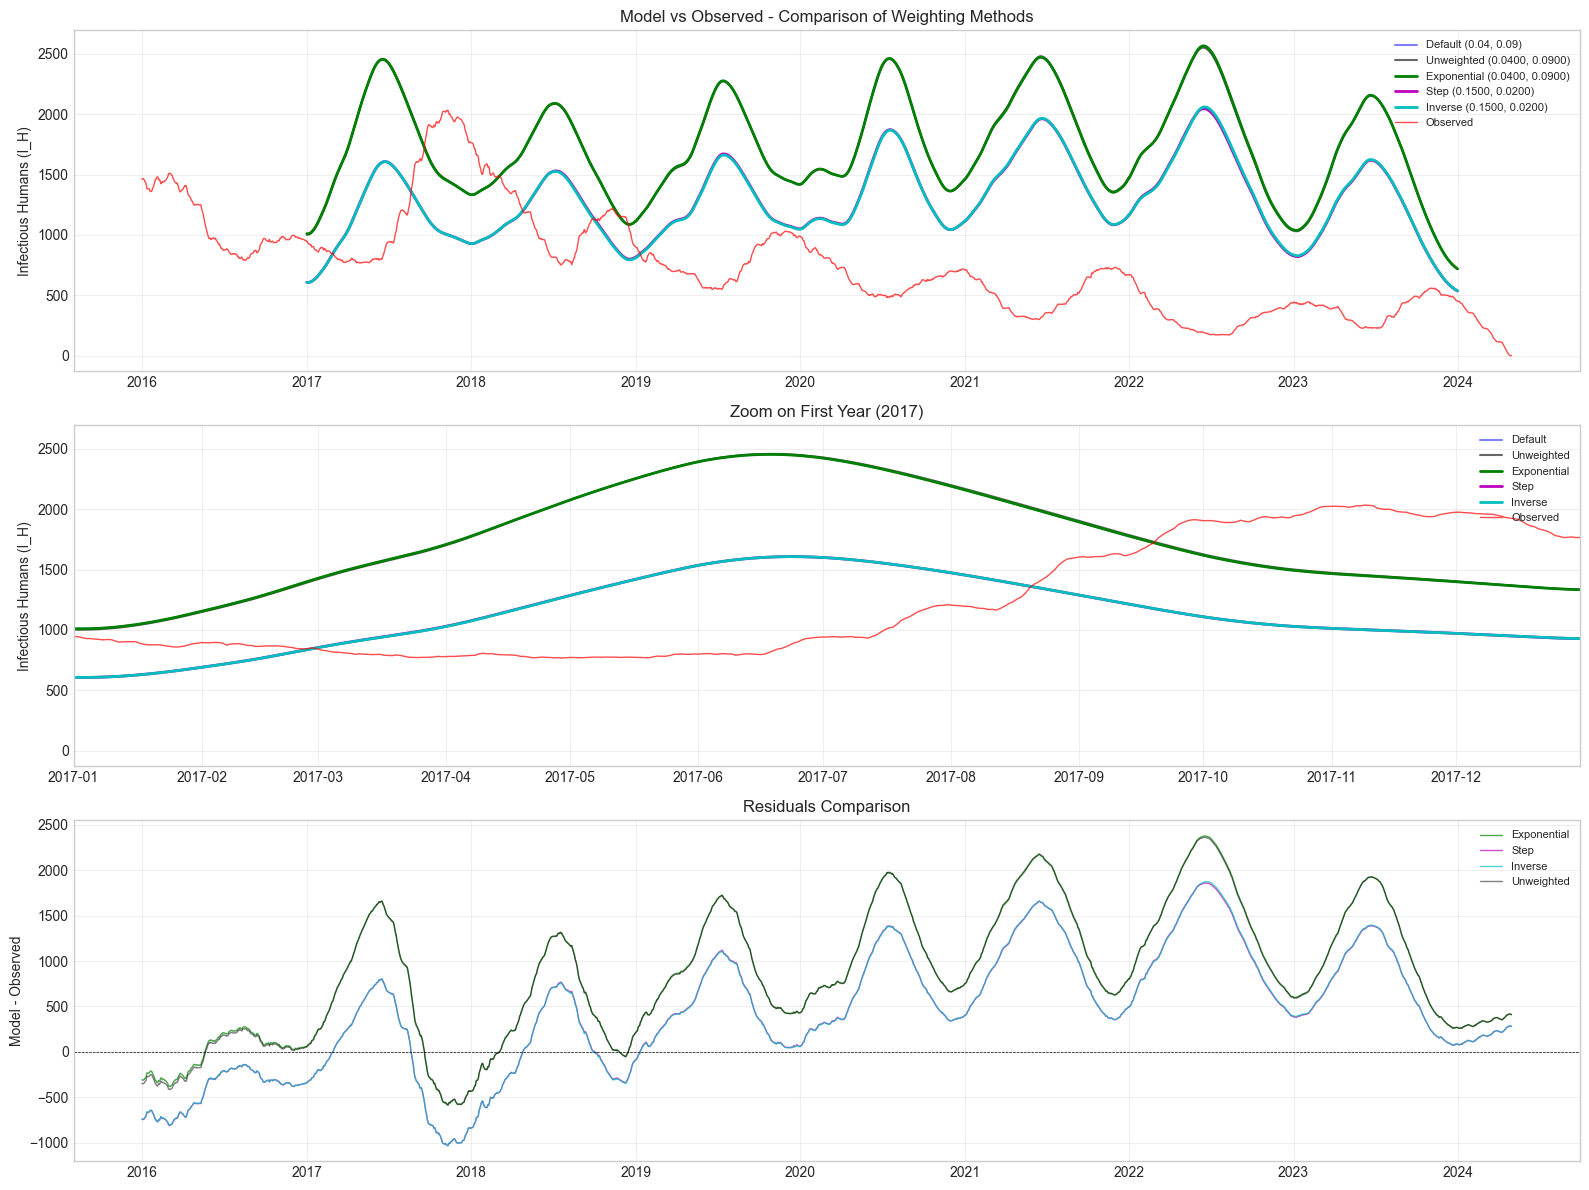

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default (0.04, 0.09)')
ax1.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label=f'Unweighted ({b1_opt_unw:.4f}, {b2_opt_unw:.4f})')
ax1.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label=f'Exponential ({b1_optimal_exp:.4f}, {b2_optimal_exp:.4f})')
ax1.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label=f'Step ({b1_optimal_step:.4f}, {b2_optimal_step:.4f})')
ax1.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label=f'Inverse ({b1_optimal_inv:.4f}, {b2_optimal_inv:.4f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)'); ax1.set_title('Model vs Observed - Comparison of Weighting Methods')
ax1.legend(loc='upper right', fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
first_year_end = pd.to_datetime('2017-12-31')
ax2.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default')
ax2.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label='Unweighted')
ax2.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label='Exponential')
ax2.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label='Step')
ax2.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label='Inverse')
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax2.set_xlim(pd.to_datetime('2017-01-01'), first_year_end)
ax2.set_ylabel('Infectious Humans (I_H)'); ax2.set_title('Zoom on First Year (2017)')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
obs_dates_int = rural_cases_df['date'].astype(np.int64).values
for dates_arr, IH_arr, label, color, alpha in [
    (dates_exp, IH_exp, 'Exponential', 'g', 0.7),
    (dates_step, IH_step, 'Step', 'm', 0.7),
    (dates_inv, IH_inv, 'Inverse', 'c', 0.7),
    (dates_unw, IH_unw, 'Unweighted', 'k', 0.5),
]:
    mi = interp1d(pd.to_datetime(dates_arr).astype(np.int64), IH_arr, kind='linear', fill_value='extrapolate')
    ax3.plot(rural_cases_df['date'], mi(obs_dates_int) - rural_cases_df['active_total'].values,
             '-', color=color, linewidth=1.0, alpha=alpha, label=label)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Model - Observed'); ax3.set_title('Residuals Comparison')
ax3.legend(loc='upper right', fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Quantitative Comparison

In [20]:
def compute_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    return np.mean((mi(rural_cases_df['date'].astype(np.int64).values) - rural_cases_df['active_total'].values) ** 2)

def compute_first_year_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    mask = rural_cases_df['date'] <= pd.to_datetime('2017-12-31')
    return np.mean((mi(rural_cases_df.loc[mask, 'date'].astype(np.int64).values) - rural_cases_df.loc[mask, 'active_total'].values) ** 2)

method_results = {
    'Default':     {'dates': dates_default, 'IH': IH_default, 'b1': 0.04, 'b2': 0.09},
    'Unweighted':  {'dates': dates_unw,     'IH': IH_unw,     'b1': b1_opt_unw, 'b2': b2_opt_unw},
    'Exponential': {'dates': dates_exp,     'IH': IH_exp,     'b1': b1_optimal_exp, 'b2': b2_optimal_exp},
    'Step':        {'dates': dates_step,    'IH': IH_step,    'b1': b1_optimal_step, 'b2': b2_optimal_step},
    'Inverse':     {'dates': dates_inv,     'IH': IH_inv,     'b1': b1_optimal_inv, 'b2': b2_optimal_inv},
}

print("=" * 80)
print("QUANTITATIVE COMPARISON")
print("=" * 80)
print(f"{'Method':<15} {'Overall MSE':>15} {'First Year MSE':>15} {'b1':>10} {'b2':>10}")
print("-" * 80)

for name, data in method_results.items():
    overall = compute_mse(data['dates'], data['IH'])
    first_yr = compute_first_year_mse(data['dates'], data['IH'])
    print(f"{name:<15} {overall:>15,.2f} {first_yr:>15,.2f} {data['b1']:>10.6f} {data['b2']:>10.6f}")

print("=" * 80)

QUANTITATIVE COMPARISON
Method              Overall MSE  First Year MSE         b1         b2
--------------------------------------------------------------------------------
Default            1,235,716.64      430,396.82   0.040000   0.090000
Unweighted         1,232,639.99      432,793.50   0.040000   0.090000
Exponential        1,235,716.64      430,396.82   0.040000   0.090000
Step                 630,264.92      303,139.21   0.150003   0.019998
Inverse              631,939.55      302,104.77   0.150008   0.020000


---
## Summary: Best Parameters

In [22]:
saved = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}

print("=" * 70)
print("BEST WEIGHTED PARAMETERS (Force of Infection)")
print("=" * 70)

for method in ['exponential', 'step', 'inverse']:
    params = saved.get(method, {})
    if params:
        b1v = params['b1']
        b2v = params['b2']
        print(f"\n{method.upper()}:")
        print(f"  b1 = {b1v:.6f} (mosquito-to-human transmission)")
        print(f"  b2 = {b2v:.6f} (human-to-mosquito transmission)")

print("\n" + "=" * 70)

BEST WEIGHTED PARAMETERS (Force of Infection)

EXPONENTIAL:
  b1 = 0.040000 (mosquito-to-human transmission)
  b2 = 0.090000 (human-to-mosquito transmission)

STEP:
  b1 = 0.150003 (mosquito-to-human transmission)
  b2 = 0.019998 (human-to-mosquito transmission)

INVERSE:
  b1 = 0.150008 (mosquito-to-human transmission)
  b2 = 0.020000 (human-to-mosquito transmission)

